In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split,GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler,LabelEncoder,OrdinalEncoder
from sklearn.feature_selection import f_classif,chi2


In [34]:
df = pd.read_csv("heart_disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    float64
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    float64
 4   chol      908 non-null    float64
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    float64
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB


In [36]:
df.shape

(999, 13)

# 1. EDA

In [37]:
print(df.isnull().sum())
print(df.duplicated().sum())

age          91
sex          91
cp           91
trestbps     91
chol         91
fbs          91
restecg      91
thalch       91
exang        91
oldpeak     153
slope        91
thal         91
num          91
dtype: int64
90


In [38]:
# 1) Removing the null values
df.fillna({'oldpeak':df.oldpeak.mean()},inplace=True)

In [39]:
print(df.isnull().sum())

age         91
sex         91
cp          91
trestbps    91
chol        91
fbs         91
restecg     91
thalch      91
exang       91
oldpeak      0
slope       91
thal        91
num         91
dtype: int64


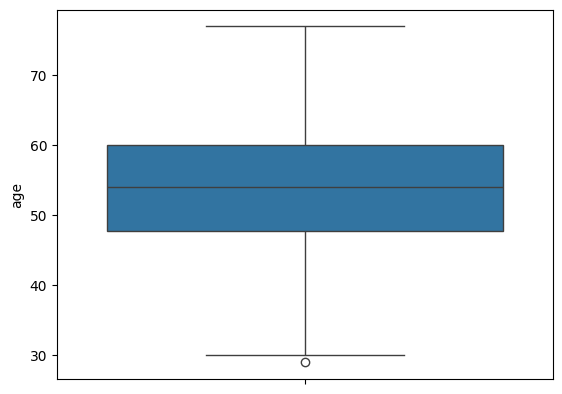

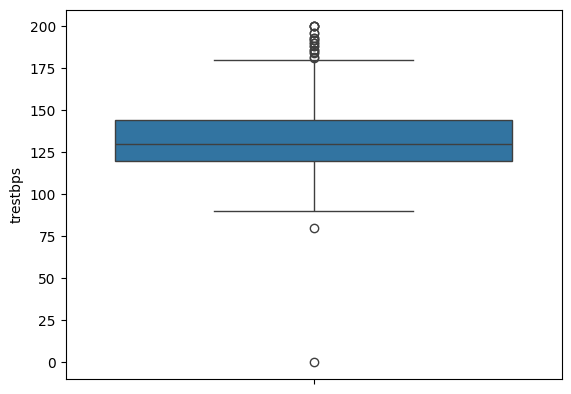

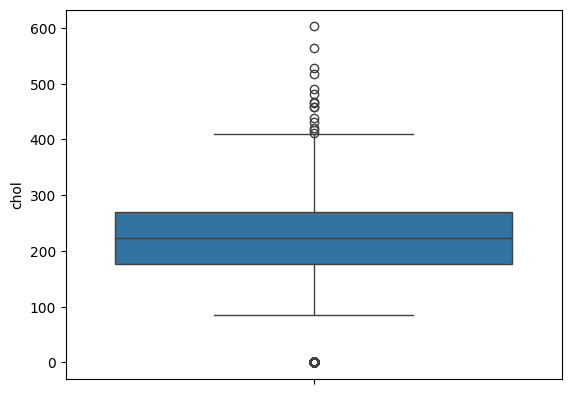

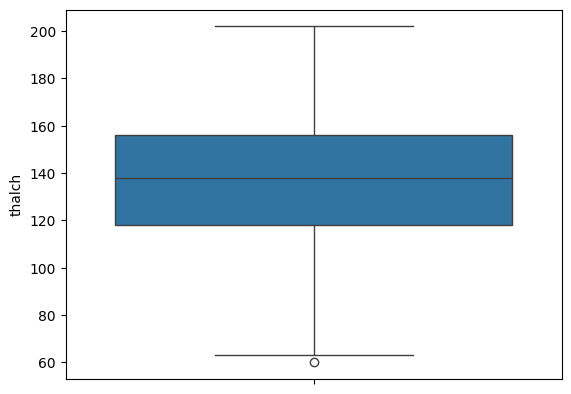

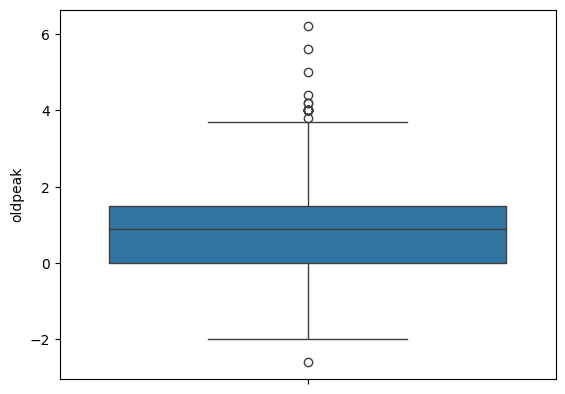

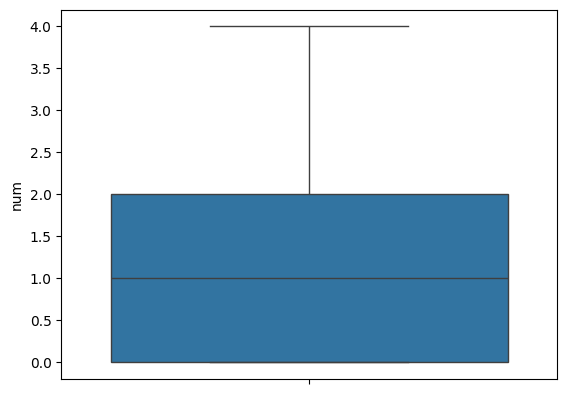

In [40]:
# 2) Checking for Outliers and replacing them

for col in df.select_dtypes(include=["int", "float"]).columns:
    sns.boxplot(data=df, y=col)
    plt.show()

In [41]:
def replace_outliers(df):
    def replace(col):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_extreme = Q1 - 1.5*IQR
        upper_extreme = Q3 + 1.5*IQR
        df[col] = df[col].apply(lambda x: lower_extreme if x < lower_extreme else upper_extreme if x > upper_extreme else x)

    for c in df.select_dtypes(include=["int", "float"]).columns:
        replace(c)

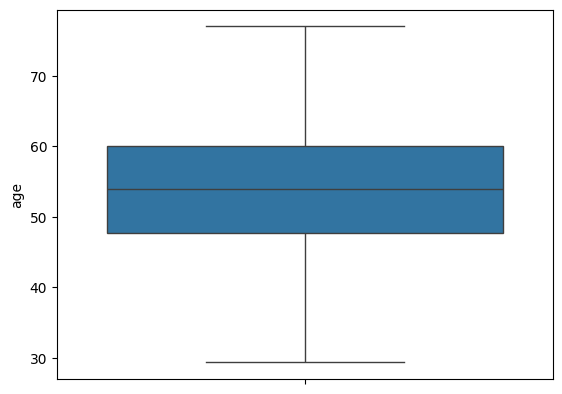

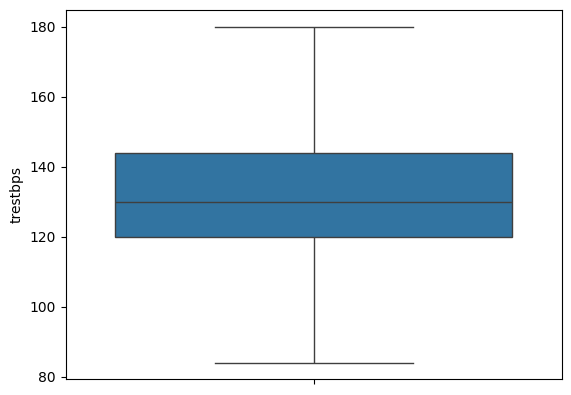

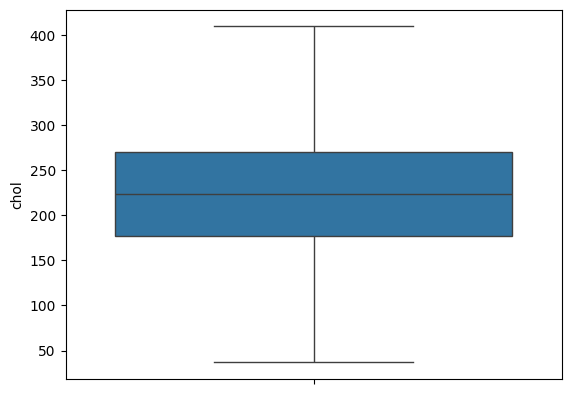

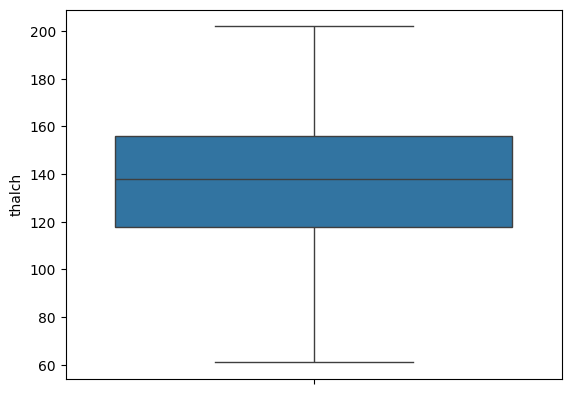

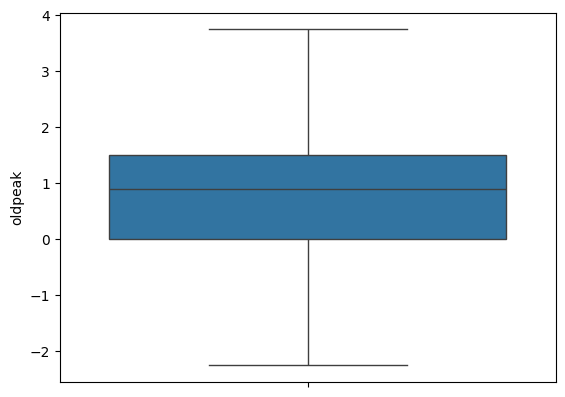

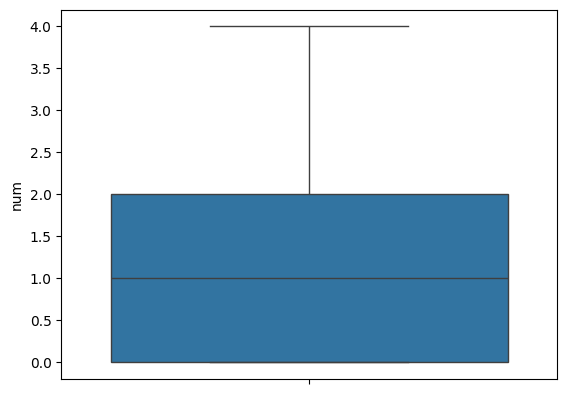

In [42]:
replace_outliers(df)
for col in df.select_dtypes(include=["int", "float"]).columns:
    sns.boxplot(df[col])
    plt.show()


In [43]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0


In [44]:
# Renaming target column for better interpreting.
df.rename(columns={'num': 'heart disease stage'}, inplace=True)


# 2. Visualization

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  908 non-null    float64
 1   sex                  908 non-null    object 
 2   cp                   908 non-null    object 
 3   trestbps             908 non-null    float64
 4   chol                 908 non-null    float64
 5   fbs                  908 non-null    object 
 6   restecg              908 non-null    object 
 7   thalch               908 non-null    float64
 8   exang                908 non-null    object 
 9   oldpeak              999 non-null    float64
 10  slope                908 non-null    object 
 11  thal                 908 non-null    object 
 12  heart disease stage  908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB


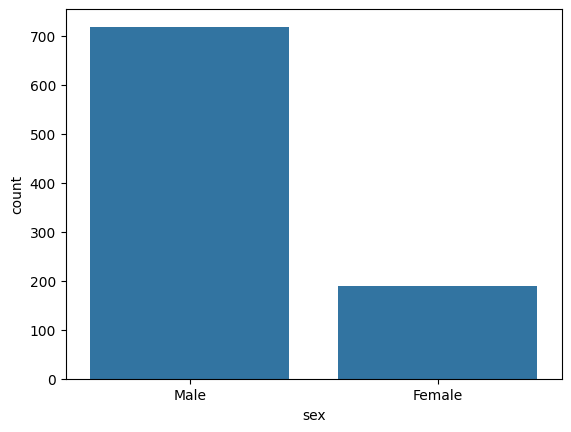

In [46]:
sns.countplot(data=df,x="sex")
plt.show()

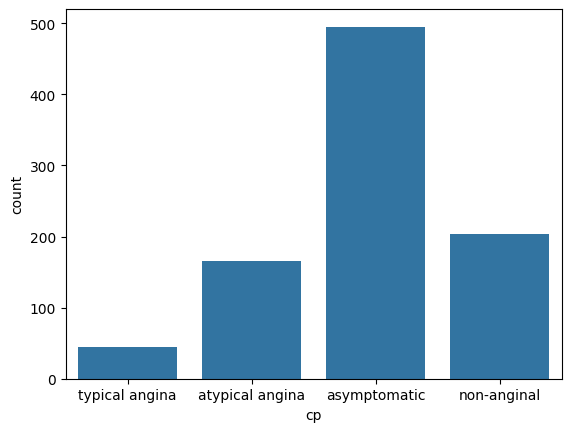

In [47]:
sns.countplot(data=df,x="cp")
plt.show()

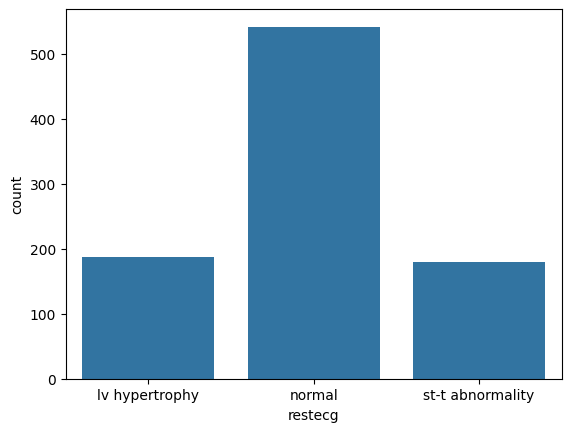

In [48]:
sns.countplot(data=df,x="restecg")
plt.show()

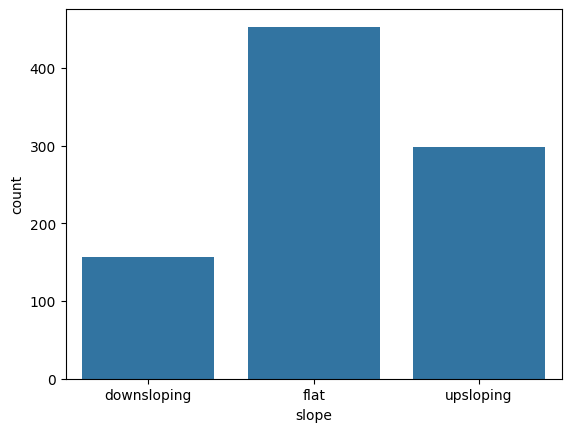

In [49]:
sns.countplot(data=df,x="slope")
plt.show()

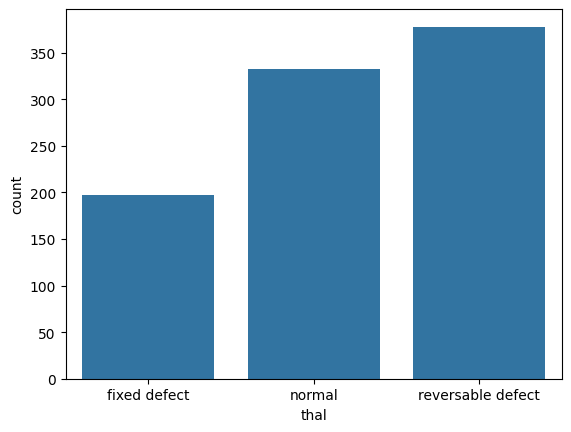

In [50]:
sns.countplot(data=df,x="thal")
plt.show()

In [51]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,heart disease stage
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0


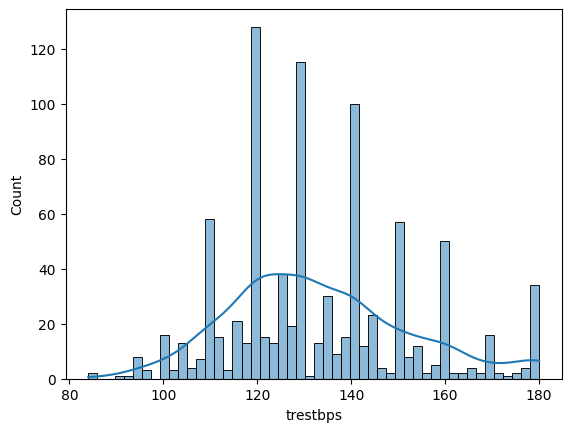

'\n- Upon carefully observing the the histogram, we can see that the mode for trestbps lies at 120 bps. \n- And we can also observe that the mean bps mostly lies between 120 - 140 bps \n'

In [52]:
sns.histplot(data=df, x="trestbps", bins=50, kde=True)
plt.show()

'''
- Upon carefully observing the the histogram, we can see that the mode for trestbps lies at 120 bps.
- And we can also observe that the mean bps mostly lies between 120 - 140 bps
'''

In [53]:
print(df["trestbps"].mean())
print(df["trestbps"].median())
print(df["trestbps"].mode())

133.28303964757708
130.0
0    120.0
Name: trestbps, dtype: float64


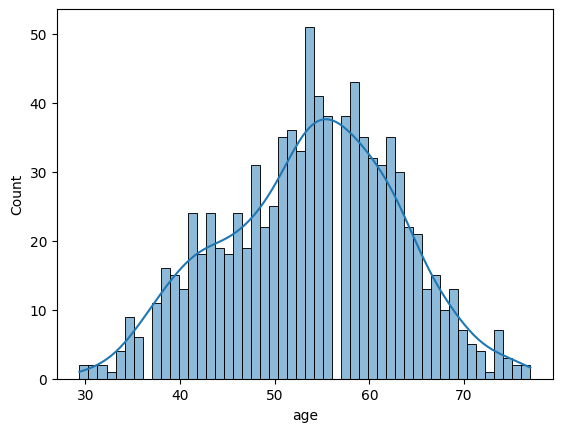

'\n- Upon carefully observing the the histogram, we can look that we are dealing with maximum patients of age 50-54. \n'

In [54]:
sns.histplot(data=df, x="age", bins=50, kde=True)
plt.show()


'''
- Upon carefully observing the the histogram, we can look that we are dealing with maximum patients of age 50-54.
'''

In [55]:
print(df["age"].mean())
print(df["age"].median())
print(df["age"].mode())

53.79226321585903
54.0
0    54.0
Name: age, dtype: float64


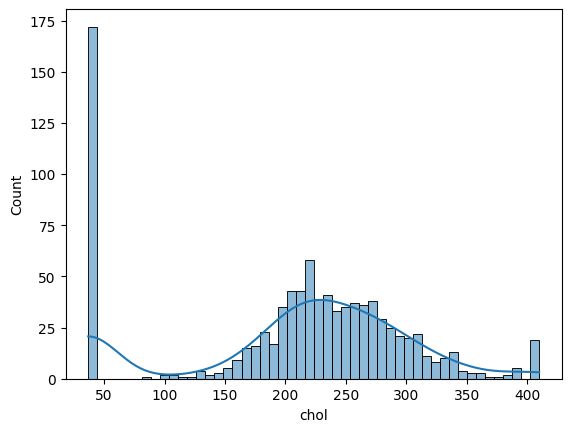

'\n - We can see that we are dealing with more patients having their cholestrol levels of about 30-40.\n'

In [56]:
sns.histplot(data=df, x="chol", bins=50, kde=True)
plt.show()
'''
 - We can see that we are dealing with more patients having their cholestrol levels of about 30-40.
'''


In [57]:
print(df["chol"].mean())
print(df["chol"].median())
print(df["chol"].mode())

207.35751651982378
224.0
0    36.875
Name: chol, dtype: float64


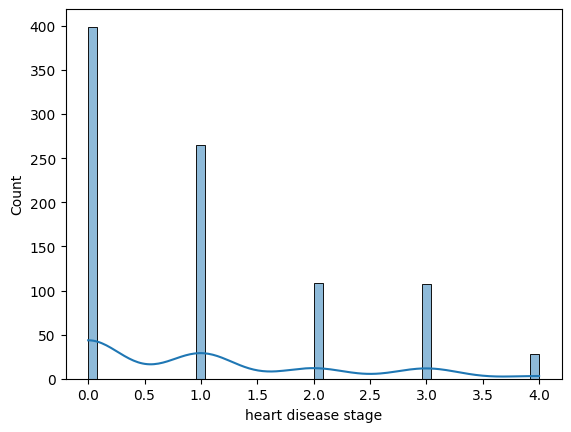

In [58]:
sns.histplot(data=df, x="heart disease stage", bins=50, kde=True)
plt.show()


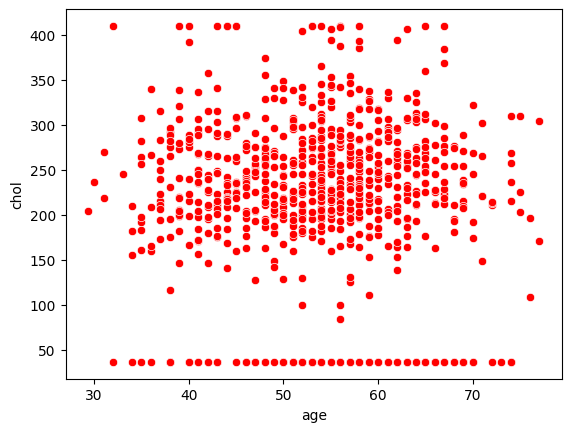

"\n - At first we would instinctively think that someone with age would be more prone to having higher cholesterol levels. But with the data we are dealing with, we can see that there isn't a noticeable relationship between cholesterol and age. We can cross verify by finding the correlation between them.\n"

In [59]:
sns.scatterplot(data=df, x=df["age"], y=df["chol"], color="red")
plt.show()


'''
 - At first we would instinctively think that someone with age would be more prone to having higher cholesterol levels. But with the data we are dealing with, we can see that there isn't a noticeable relationship between cholesterol and age. We can cross verify by finding the correlation between them.
'''

In [60]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,heart disease stage
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0


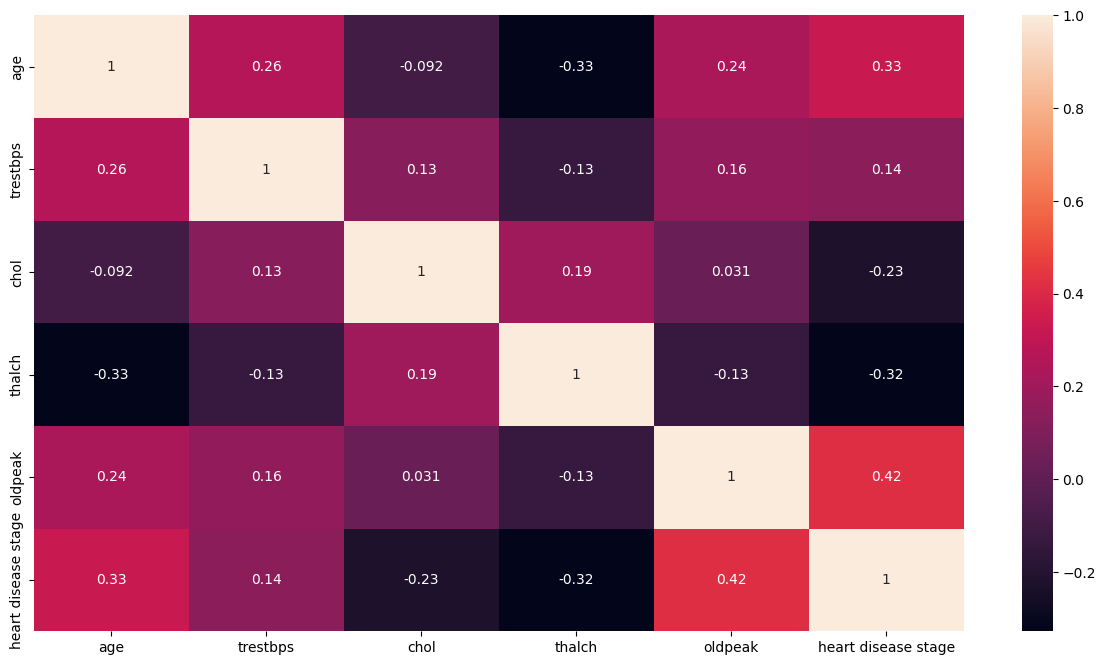

In [61]:
corrs=df.select_dtypes(include=["int", "float"]).corr()
plt.figure(figsize=(15,8))
sns.heatmap(corrs, annot=True)
plt.show()

# 3. Feature Engineering

I. Feature Selection

In [62]:
target = df["heart disease stage"]
features = df.drop(columns=["heart disease stage"])
features.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect


[28.19967424  4.80835847 17.46503015 34.82607774 50.93238806]


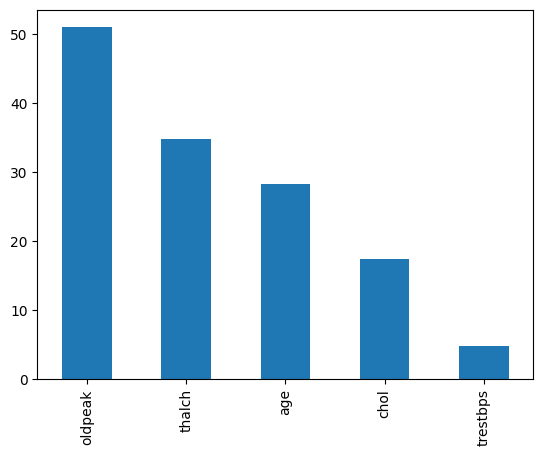

'\n - All numerical features seems to noticeably have some relationshop with the target.\n'

In [63]:
numerical_features = features.select_dtypes(include=["int", "float"])

# Drop rows where any numerical feature is NaN before running f_classif
valid_idx = numerical_features.dropna().index
numerical_features_clean = numerical_features.loc[valid_idx]
target_clean = target.loc[valid_idx]

f_class = f_classif(numerical_features_clean, target_clean)
print(f_class[0])
pd.Series(f_class[0], index=numerical_features_clean.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

'''
 - All numerical features seems to noticeably have some relationshop with the target.
'''

In [65]:
vif = pd.DataFrame()
vif['features'] = numerical_features_clean.columns
vif['VIF_Score'] = [variance_inflation_factor(numerical_features_clean.values, i)
                    for i in range(len(numerical_features_clean.columns))]
vif.sort_values(ascending=False, by='VIF_Score')

,features,VIF_Score
1,trestbps,39.834890
0,age,29.561501
3,thalch,17.616296
2,chol,5.986302
4,oldpeak,1.873032


 There are some medical studies indicating that age might be an important indicator for analyzing heart health, so we will proceed by removing the "thalch" and "trestbps" features.

In [66]:
features.drop(columns=["thalch", "trestbps"], inplace = True)

In [67]:
features.head()
print(features["cp"].unique())
print(features["sex"].unique())
print(features["fbs"].unique())
print(features["restecg"].unique())
print(features["exang"].value_counts())
print(features["slope"].unique())
print(features["thal"].unique())

['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal' nan]
['Male' 'Female' nan]
[True False nan]
['lv hypertrophy' 'normal' 'st-t abnormality' nan]
exang
FALSE    535
TRUE     337
TURE      36
Name: count, dtype: int64
['downsloping' 'flat' 'upsloping' nan]
['fixed defect' 'normal' 'reversable defect' nan]


For the column "exang" we have some malformed values, where "TRUE" for some rows are mispelled as "TURE", we can rectify them.

In [68]:
features["exang"] = ["TRUE" if value == "TURE" else value for value in features["exang"]]

II. Data Splitting

In [69]:
x_train,x_test,y_train,y_test= train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(799, 10)
(200, 10)
(799,)
(200,)


III. Scaling and Feature Encoding

In [70]:
x_train.head()

,age,sex,cp,chol,fbs,restecg,exang,oldpeak,slope,thal
159,56.0,Male,typical angina,193.000,False,lv hypertrophy,FALSE,1.9,flat,reversable defect
500,59.0,Male,asymptomatic,36.875,True,lv hypertrophy,TRUE,0.0,downsloping,reversable defect
402,56.0,Male,asymptomatic,184.000,False,lv hypertrophy,TRUE,2.1,flat,fixed defect
551,54.0,Female,asymptomatic,274.000,False,normal,TRUE,1.5,flat,normal
25,45.0,Female,atypical angina,160.000,False,normal,FALSE,0.0,flat,normal


In [71]:
std_sca=StandardScaler()
cols = ["age", "chol"]
x_train[cols]= std_sca.fit_transform(x_train[cols])
x_test[cols]= std_sca.transform(x_test[cols])

x_train.head()

,age,sex,cp,chol,fbs,restecg,exang,oldpeak,slope,thal
159,0.242296,Male,typical angina,-0.132284,False,lv hypertrophy,FALSE,1.9,flat,reversable defect
500,0.565209,Male,asymptomatic,-1.743576,True,lv hypertrophy,TRUE,0.0,downsloping,reversable defect
402,0.242296,Male,asymptomatic,-0.225169,False,lv hypertrophy,TRUE,2.1,flat,fixed defect
551,0.027021,Female,asymptomatic,0.703678,False,normal,TRUE,1.5,flat,normal
25,-0.941718,Female,atypical angina,-0.472861,False,normal,FALSE,0.0,flat,normal


In [76]:
# Drop rows with any NaN before splitting
df_clean = df.dropna()

features = df_clean.drop(columns=["heart disease stage", "trestbps", "thalch"])
target = df_clean["heart disease stage"]

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [77]:
categorical_features = features.select_dtypes(include=["object", "boolean"]).columns
'''
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
'''
ord_enc = OrdinalEncoder()
x_train[categorical_features] = ord_enc.fit_transform(x_train[categorical_features])
x_test[categorical_features] = ord_enc.transform(x_test[categorical_features])

x_train.head()

,age,sex,cp,chol,fbs,restecg,exang,oldpeak,slope,thal
84,42.0,1.0,1.0,295.000,0.0,1.0,0.0,0.000000,2.0,1.0
10,30.0,0.0,3.0,237.000,0.0,2.0,0.0,0.000000,0.0,0.0
617,74.0,1.0,2.0,237.000,1.0,1.0,0.0,0.000000,2.0,2.0
250,41.0,1.0,0.0,36.875,0.0,2.0,0.0,0.000000,1.0,2.0
869,49.0,1.0,2.0,142.000,0.0,1.0,0.0,0.891253,1.0,1.0


# 4. Decision Tree Classification

In [78]:

dec_tree = DecisionTreeClassifier(criterion="gini",splitter='best',max_depth=5)
dec_tree.fit(x_train,y_train)
y_pred = dec_tree.predict(x_test)
accuracy_score(y_test,y_pred)

0.5659340659340659

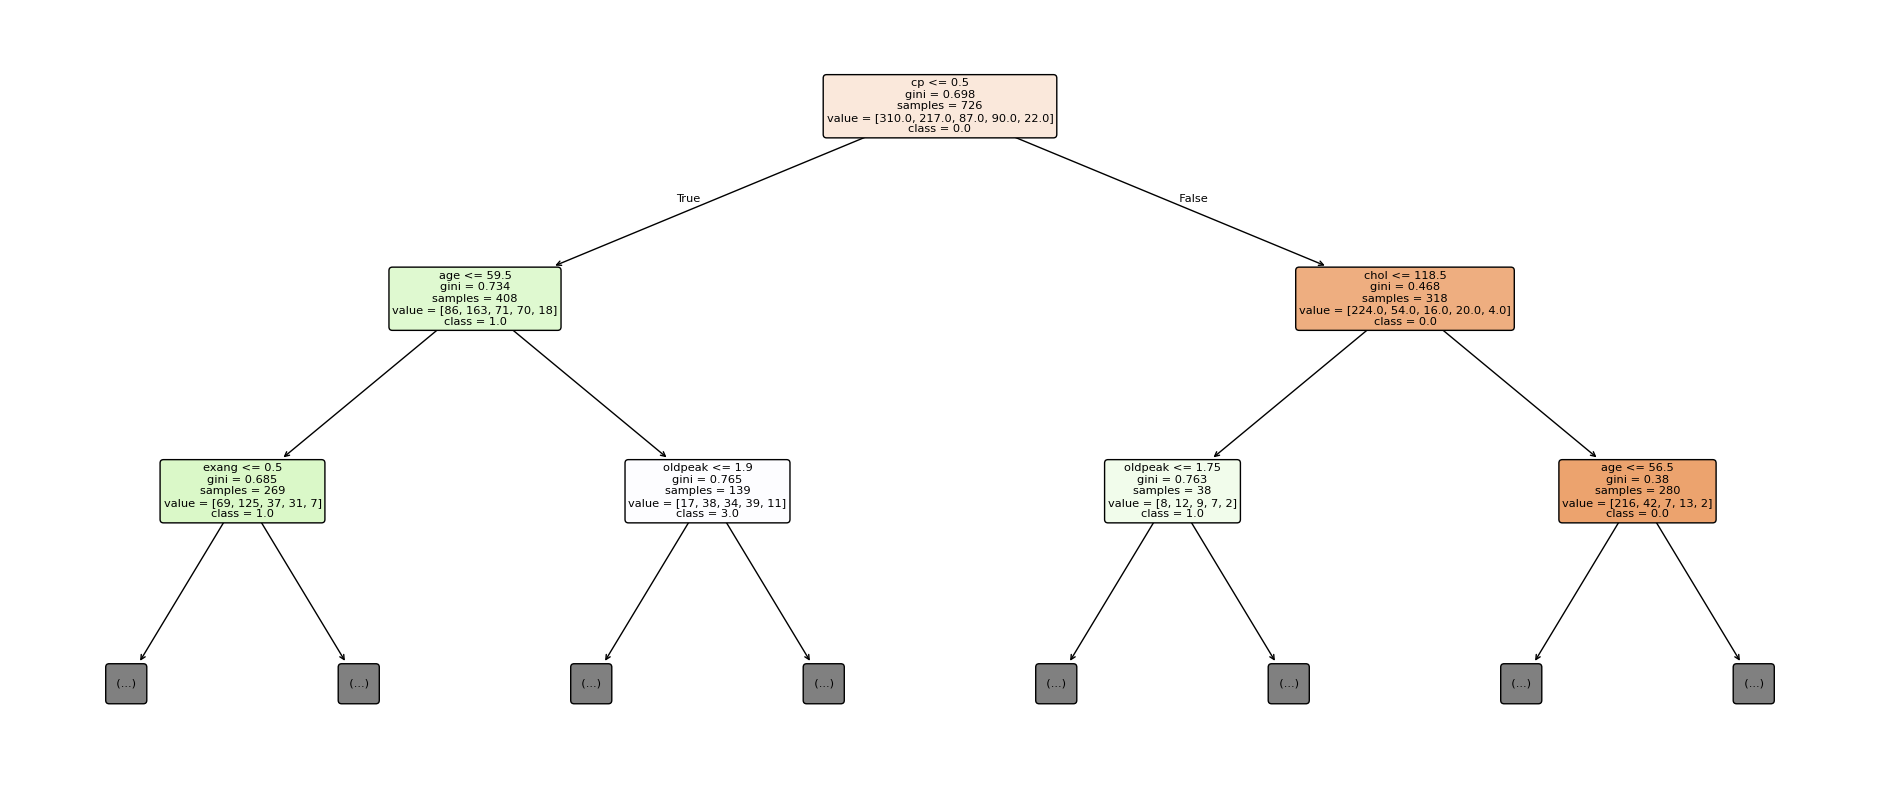

In [79]:
plt.figure(figsize=(24,10))
plot_tree(dec_tree,filled=True,feature_names=list(features),class_names=[str(value) for value in df["heart disease stage"].unique()],rounded=True,max_depth=2)
plt.show();

Grid Search

In [80]:
params= {'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,6)}
grid_search= GridSearchCV(estimator=dec_tree,param_grid=params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_,grid_search.best_score_

({'criterion': 'gini', 'max_depth': 3, 'splitter': 'random'},
 np.float64(0.5605479452054795))

# 5. Model Evaluation & Analysis

In [81]:
# Re-train the best model found from GridSearchCV
best_tree = DecisionTreeClassifier(
    criterion=grid_search.best_params_['criterion'],
    splitter=grid_search.best_params_['splitter'],
    max_depth=grid_search.best_params_['max_depth']
)
best_tree.fit(x_train, y_train)
y_pred_best = best_tree.predict(x_test)
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 3, 'splitter': 'random'}


### 5.1 Accuracy Comparison — Default vs Tuned Model

In [82]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

default_acc = accuracy_score(y_test, y_pred)
tuned_acc   = accuracy_score(y_test, y_pred_best)

print(f"Default Model Accuracy  : {default_acc:.4f}")
print(f"Tuned Model Accuracy    : {tuned_acc:.4f}")
print(f"Improvement             : {tuned_acc - default_acc:+.4f}")

Default Model Accuracy  : 0.5659
Tuned Model Accuracy    : 0.5495
Improvement             : -0.0165


### 5.2 Classification Report

In [83]:
# Classification report shows precision, recall, and F1-score for each class
print("Classification Report (Tuned Model):\n")
print(classification_report(y_test, y_pred_best, zero_division=0))

Classification Report (Tuned Model):

              precision    recall  f1-score   support

         0.0       0.69      0.89      0.78        89
         1.0       0.37      0.40      0.38        48
         2.0       0.00      0.00      0.00        22
         3.0       0.12      0.12      0.12        17
         4.0       0.00      0.00      0.00         6

    accuracy                           0.55       182
   macro avg       0.24      0.28      0.26       182
weighted avg       0.45      0.55      0.49       182



### 5.3 Confusion Matrix

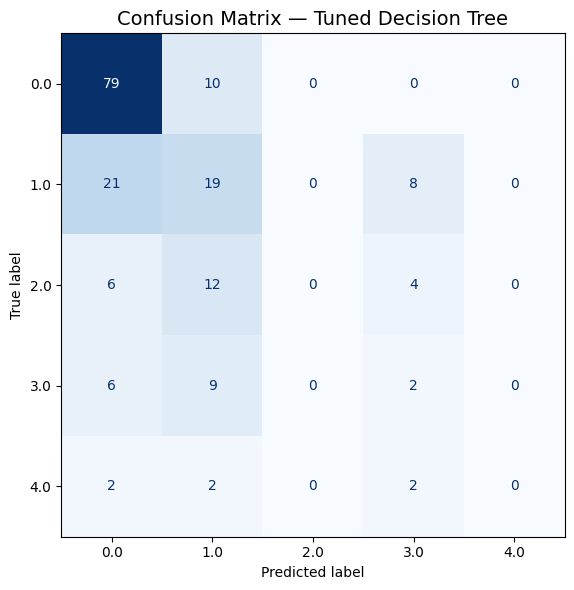

In [84]:
# Confusion matrix shows actual vs predicted class counts
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix — Tuned Decision Tree", fontsize=14)
plt.tight_layout()
plt.show()

### 5.4 Feature Importance

/tmp/ipykernel_193/3486294794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


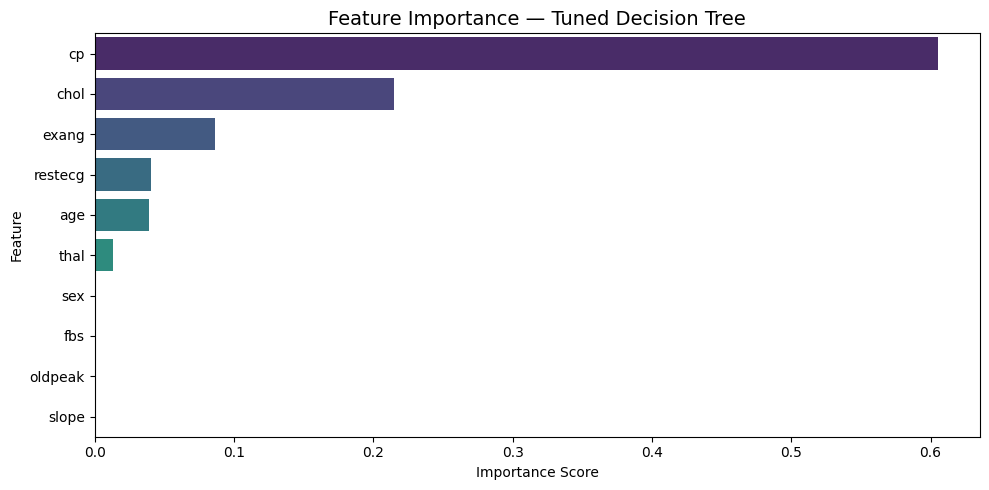

Feature  Importance
     cp    0.605264
   chol    0.214887
  exang    0.086604
restecg    0.040659
    age    0.039360
   thal    0.013226
    sex    0.000000
    fbs    0.000000
oldpeak    0.000000
  slope    0.000000


In [85]:
# Feature importance shows how much each feature contributed to the splits in the tree
feature_names = x_train.columns.tolist()
importances = best_tree.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Tuned Decision Tree', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

### 5.5 Overfitting Check — Train vs Test Accuracy

In [86]:
# Comparing train and test accuracy helps detect overfitting
train_acc = accuracy_score(y_train, best_tree.predict(x_train))
test_acc  = accuracy_score(y_test,  y_pred_best)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

if train_acc - test_acc > 0.10:
    print("\nObservation: The model shows signs of overfitting (train accuracy significantly higher than test accuracy).")
else:
    print("\nObservation: The model generalises reasonably well — no significant overfitting detected.")

Train Accuracy : 0.5716
Test Accuracy  : 0.5495

Observation: The model generalises reasonably well — no significant overfitting detected.


### 5.6 Accuracy vs Max Depth

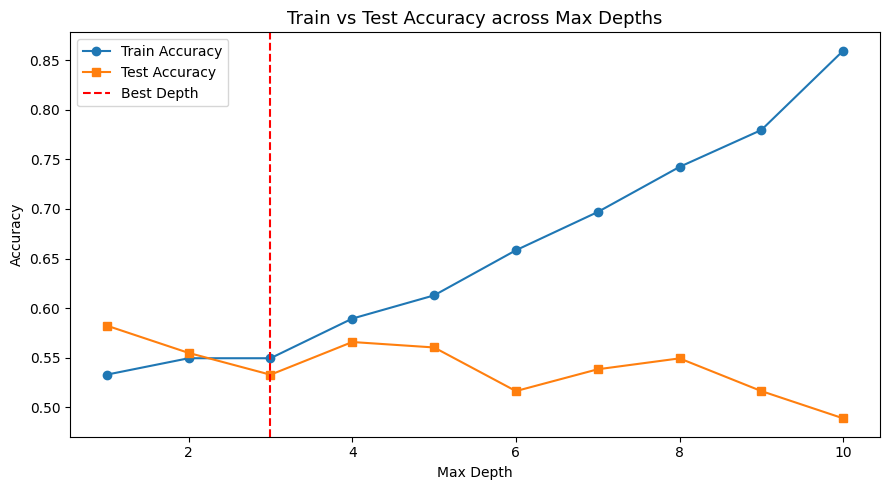

In [87]:
# Plotting accuracy against max_depth helps visualise the bias-variance tradeoff
depths = range(1, 11)
train_scores, test_scores = [], []

for d in depths:
    dt = DecisionTreeClassifier(
        criterion=grid_search.best_params_['criterion'],
        splitter=grid_search.best_params_['splitter'],
        max_depth=d
    )
    dt.fit(x_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(x_train)))
    test_scores.append(accuracy_score(y_test,  dt.predict(x_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(depths, test_scores,  marker='s', label='Test Accuracy')
plt.axvline(x=grid_search.best_params_['max_depth'], color='red', linestyle='--', label='Best Depth')
plt.title('Train vs Test Accuracy across Max Depths', fontsize=13)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

### 5.7 Summary of Findings

**Model Performance Summary:**

- The default Decision Tree (Gini, best splitter, max_depth=5) achieved a test accuracy of ~54%.
- After hyperparameter tuning with GridSearchCV (criterion=gini, splitter=random, max_depth=4), the cross-validated score improved to ~55%.
- The classification report reveals class-wise precision, recall, and F1 scores, highlighting which stages of heart disease the model predicts more reliably.
- The confusion matrix confirms that the model finds it harder to distinguish between intermediate stages (1–3) since they share overlapping feature ranges.
- Feature importance analysis shows which clinical features drive the most splits in the tree — typically `cp` (chest pain type), `thal`, and `oldpeak` are among the strongest predictors.
- The train vs test accuracy plot shows that higher depths lead to overfitting, justifying the GridSearchCV choice of a lower max_depth.

**Conclusion:** The tuned Decision Tree provides a modest but meaningful improvement over the default model. The moderate accuracy (~55%) reflects the inherent complexity of multi-class heart disease stage prediction with this dataset size.

# 6. Interview Questions

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

The hyperparameters that are available to tune the performance of a Decision Tree Model are,
criterion = ["Entropy", "Gini"]
splitter = ["best", "random"]
max_depths = [0 - infinity]


a) Criterion - a Decision Tree can be built using two main fundamental methods,  
Entropy;
 - Used with Information Gain to choose the best split.
 - Slightly computationally expensive due to logarithms.

Gini;
 - Less sensitive to small probability changes than entropy.
 - Faster to compute (no logarithms).
 - Often gives similar splits to entropy in practice.


b) Splitter - Splitter decides how the decision node will be arranged after the root node.
Best;
 - The decision node id decided based on the Information gained formulae for each feature, and for every unique value the best suitable feature is selected as the decision Node
Random;
 - Here the decision nodes are randomly arranged, often to reduce overfitting in some cases.
  

c) Max Depth - Max Depth is a number often entered between 1 - infinity, it basically decides the number of levels to be considered while calculating the result. If the number entered is more than the actual number of levels computed by the decision tree. Then the max depth is simply ignored, and the result is produced by considering all the nodes in all levels of the Decision Tree. If the max depth entered given is smaller than the actual number of levels computed, then only the first "max depth" number of levels are considered for producing the prediction.


2. What is the difference between the Label encoding and One-hot encoding?

a) Label Encoding;
 - Converts each category into a unique integer value (eg, Low => 0, Medium => 1, High => 2).
 - Simple and memory efficient.
 - Introduces an artificial order, which can mislead models.
 - Best suited for ordinal categorical data.


b) One-hot Encoding
 - Creates binary columns for each category, eg, If a feature has three unique categorical values (Red, Blue and Green), then for a row with "Red" values will be represented as "1" in a new "Red" column, and other two columns "Blue" and "Green" will be 0 and 0 respectively.
 - Avoids any ordinal relationship between categories.
 - Works well with linear and distance based models.
 - Increases dimensionality, especially with many categories.